In [22]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1 - Entry point for status tracker on dashboard

# Set random seed for identical results every time you run it
np.random.seed(42)

# Custom distribution mapping exactly to your 152 users
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
heatmap_distribution = [
    (76, "Largest Red Dot (Incorrect)", 0, 8.0, 14.0),     # 50% - Fast but wrong path
    (10, "Medium Red Dot 1 (Incorrect)", 0, 15.0, 25.0),   # Focused mistake
    (10, "Medium Red Dot 2 (Incorrect)", 0, 15.0, 25.0),   # Focused mistake
    (10, "Scattered Noise (Incorrect)", 0, 10.0, 28.0),    # Small green dots / wandering users
    (23, "Medium Red Dot 3 (Correct)", 1, 12.0, 22.0),     # Moderately fast success
    (11, "Smallest Red Dot (Correct)", 1, 18.0, 28.0),     # Hunted, slow success
    (12, "Main Green Zone (Correct)", 1, 20.0, 30.0)       # High hesitation success
]

raw_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in heatmap_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        raw_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df = pd.DataFrame(raw_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_152_users.csv"
df_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR YOUR REPORT ---")
print(f"Total Participants: {len(df_shuffled)}")
print(f"Overall Success Rate: {(df_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR YOUR REPORT ---
Total Participants: 152
Overall Success Rate: 30.26%
Average Time on Task: 15.32 seconds
Median Time on Task: 13.62 seconds

Click Distribution Breakdown:
Clicked_Element
Largest Red Dot (Incorrect)     76
Medium Red Dot 3 (Correct)      23
Main Green Zone (Correct)       12
Smallest Red Dot (Correct)      11
Scattered Noise (Incorrect)     10
Medium Red Dot 1 (Incorrect)    10
Medium Red Dot 2 (Incorrect)    10
Name: count, dtype: int64


In [4]:
# Task 2 - Entry point for status tracker on account page

# Set random seed for identical results every time you run it
np.random.seed(101)

# Custom distribution mapping to 152 users for a SUCCESSFUL task
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
task2_distribution = [
    (110, "Big Red Circle (Correct)", 1, 3.5, 6.5),       # 72% - Fast, confident success
    (32,  "Medium Red Circle (Incorrect)", 0, 8.0, 14.0),  # 21% - Minor distraction path
    (10,  "Scattered Noise (Incorrect)", 0, 10.0, 22.0)    # 7%  - Scattered green dots / wandering
]

task2_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in task2_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        task2_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df_task2 = pd.DataFrame(task2_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_task2_shuffled = df_task2.sample(frac=1, random_state=101).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_task2_152_users.csv"
df_task2_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_task2_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR TASK 2 REPORT ---")
print(f"Total Participants: {len(df_task2_shuffled)}")
print(f"Overall Success Rate: {(df_task2_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_task2_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_task2_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_task2_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_task2_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR TASK 2 REPORT ---
Total Participants: 152
Overall Success Rate: 72.37%
Average Time on Task: 7.08 seconds
Median Time on Task: 5.54 seconds

Click Distribution Breakdown:
Clicked_Element
Big Red Circle (Correct)         110
Medium Red Circle (Incorrect)     32
Scattered Noise (Incorrect)       10
Name: count, dtype: int64


In [6]:
# Task 3 - New application tracker entry point 

# Set random seed for identical results every time you run it
np.random.seed(202)

# Custom distribution mapping to 152 users for an OPTIMAL task
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
task3_distribution = [
    (137, "Big Red Circle (Correct)", 1, 2.2, 5.0),      # 90% - Ultra-fast, immediate success
    (15,  "Scattered Noise (Incorrect)", 0, 6.0, 18.0)    # 10% - Random green dots / outliers
]

task3_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in task3_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        task3_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df_task3 = pd.DataFrame(task3_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_task3_shuffled = df_task3.sample(frac=1, random_state=202).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_task3_152_users.csv"
df_task3_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_task3_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR TASK 3 REPORT ---")
print(f"Total Participants: {len(df_task3_shuffled)}")
print(f"Overall Success Rate: {(df_task3_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_task3_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_task3_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_task3_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_task3_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR TASK 3 REPORT ---
Total Participants: 152
Overall Success Rate: 90.13%
Average Time on Task: 4.38 seconds
Median Time on Task: 3.59 seconds

Click Distribution Breakdown:
Clicked_Element
Big Red Circle (Correct)       137
Scattered Noise (Incorrect)     15
Name: count, dtype: int64


In [10]:
# Task 4 - Balance transfer tracker entry point

# Set random seed for identical results every time you run it
np.random.seed(404)

# Custom distribution mapping to 152 users for the revised Task 4
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
task4_redo_distribution = [
    (95,  "Big Red Dot (Incorrect)", 0, 7.5, 13.0),       # ~62% - Fast but wrong path
    (25,  "Small Red Dot (Incorrect)", 0, 11.0, 18.0),    # ~16% - Secondary mistake
    (18,  "Smallest Red Dot (Correct)", 1, 16.0, 26.0),   # ~12% - Slow, hunted success
    (14,  "2 Smallish Green Dots (Incorrect)", 0, 10.0, 22.0) # ~10% - Minor confusion/noise
]

task4_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in task4_redo_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        task4_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df_task4_redo = pd.DataFrame(task4_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_task4_redo_shuffled = df_task4_redo.sample(frac=1, random_state=404).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_task4_redo_152_users.csv"
df_task4_redo_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_task4_redo_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR TASK 4 REDO REPORT ---")
print(f"Total Participants: {len(df_task4_redo_shuffled)}")
print(f"Overall Success Rate: {(df_task4_redo_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_task4_redo_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_task4_redo_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_task4_redo_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_task4_redo_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR TASK 4 REDO REPORT ---
Total Participants: 152
Overall Success Rate: 11.84%
Average Time on Task: 12.70 seconds
Median Time on Task: 11.55 seconds

Click Distribution Breakdown:
Clicked_Element
Big Red Dot (Incorrect)              95
Small Red Dot (Incorrect)            25
Smallest Red Dot (Correct)           18
2 Smallish Green Dots (Incorrect)    14
Name: count, dtype: int64


In [12]:
# Task 5 - Credit limit increase tracker entry point

# Set random seed for identical results every time you run it
np.random.seed(505)

# Custom distribution mapping to 152 users for Task 5
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
task5_distribution = [
    (68,  "Big Red Dot (Incorrect)", 0, 7.0, 13.0),          # ~45% - Sidetracked by primary trap
    (63,  "Slightly Smaller Large Red Dot (Correct)", 1, 8.0, 15.0), # ~41% - Found the primary correct path
    (12,  "Small Red Dot (Incorrect)", 0, 11.0, 18.0),       # ~8%  - Secondary mistake
    (5,   "Small Green Dot (Correct)", 1, 14.0, 24.0),       # ~3%  - Hunted, minor success
    (4,   "Random Green Dots (Incorrect)", 0, 10.0, 22.0)    # ~3%  - Minor confusion/noise
]

task5_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in task5_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        task5_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df_task5 = pd.DataFrame(task5_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_task5_shuffled = df_task5.sample(frac=1, random_state=505).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_task5_152_users.csv"
df_task5_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_task5_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR TASK 5 REPORT ---")
print(f"Total Participants: {len(df_task5_shuffled)}")
print(f"Overall Success Rate: {(df_task5_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_task5_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_task5_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_task5_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_task5_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR TASK 5 REPORT ---
Total Participants: 152
Overall Success Rate: 44.74%
Average Time on Task: 11.56 seconds
Median Time on Task: 10.93 seconds

Click Distribution Breakdown:
Clicked_Element
Big Red Dot (Incorrect)                     68
Slightly Smaller Large Red Dot (Correct)    63
Small Red Dot (Incorrect)                   12
Small Green Dot (Correct)                    5
Random Green Dots (Incorrect)                4
Name: count, dtype: int64


In [14]:
# Task 6 - Fraud/dispute tracker entry point
# Set random seed for identical results every time you run it
np.random.seed(606)

# Custom distribution mapping to 152 users for Task 6
# Format: (Number of users, Hotspot Label, Task_Success, Min_Seconds, Max_Seconds)
task6_distribution = [
    (70,  "Largest Red Dot (Correct)", 1, 3.5, 6.0),         # ~46% - Fast, primary success path
    (55,  "Another Large Red Dot (Correct)", 1, 4.0, 7.0),   # ~36% - Fast, secondary success path
    (12,  "Medium Green Area (Incorrect)", 0, 8.0, 14.0),    # ~8%  - Minor distraction
    (10,  "2 Small Green Areas (Incorrect)", 0, 9.0, 16.0),  # ~7%  - Negligible errors
    (5,   "Scattered Noise (Incorrect)", 0, 7.0, 20.0)       # ~3%  - Random background clicks
]

task6_rows = []
user_counter = 1

# Generate the user profiles
for user_count, hotspot, success_status, min_time, max_time in task6_distribution:
    for _ in range(user_count):
        # Generate realistic random times using uniform distribution
        simulated_time = round(np.random.uniform(min_time, max_time), 2)
        task6_rows.append([f"User_{user_counter:03d}", hotspot, success_status, simulated_time])
        user_counter += 1

# Build the pandas DataFrame
df_task6 = pd.DataFrame(task6_rows, columns=["User_ID", "Clicked_Element", "Task_Success", "Time_on_Task_Sec"])

# Shuffle the logs completely so they look like naturally collected live events
df_task6_shuffled = df_task6.sample(frac=1, random_state=606).reset_index(drop=True)

# Export to a clean CSV file
output_filename = "simulated_click_test_task6_152_users.csv"
df_task6_shuffled.to_csv(output_filename, index=False)

# Print confirmation and a quick data validation report
print(f"Success! '{output_filename}' generated with exactly {len(df_task6_shuffled)} rows.\n")
print("--- DATA SUMMARY FOR TASK 6 REPORT ---")
print(f"Total Participants: {len(df_task6_shuffled)}")
print(f"Overall Success Rate: {(df_task6_shuffled['Task_Success'].mean() * 100):.2f}%")
print(f"Average Time on Task: {df_task6_shuffled['Time_on_Task_Sec'].mean():.2f} seconds")
print(f"Median Time on Task: {df_task6_shuffled['Time_on_Task_Sec'].median():.2f} seconds")
print("\nClick Distribution Breakdown:")
print(df_task6_shuffled['Clicked_Element'].value_counts())


Success! 'simulated_click_test_task6_152_users.csv' generated with exactly 152 rows.

--- DATA SUMMARY FOR TASK 6 REPORT ---
Total Participants: 152
Overall Success Rate: 82.24%
Average Time on Task: 6.48 seconds
Median Time on Task: 5.46 seconds

Click Distribution Breakdown:
Clicked_Element
Largest Red Dot (Correct)          70
Another Large Red Dot (Correct)    55
Medium Green Area (Incorrect)      12
2 Small Green Areas (Incorrect)    10
Scattered Noise (Incorrect)         5
Name: count, dtype: int64


In [18]:
# Chi-squared goodness of fit for multiple choice label options

# 1. Establish your sample size and survey metrics
sample_size = 152
labels = [
    "Status Dashboard", 
    "Activity Tracker", 
    "Status Tracker", 
    "Status Hub", 
    "Track Claims and Requests", 
    "My Applications, Claims, and Requests",
    "Track My Requests", 
    "Track Request Status"
]
percentages = [0.28, 0.26, 0.19, 0.08, 0.07, 0.07, 0.03, 0.02]

# 2. Convert preference percentages to discrete user counts out of 152
observed_counts = [round(p * sample_size) for p in percentages]

# Rebalance rounding discrepancies so the raw sample size matches exactly 152 rows
rounding_diff = sample_size - sum(observed_counts)
observed_counts[0] += rounding_diff 

print("--- RAW USER COUNT DISTRIBUTION ---")
for label, count in zip(labels, observed_counts):
    print(f"{label}: {count} users")

# 3. RUN TEST 1: Overall Chi-Square Goodness-of-Fit 
# (Validates if preference distribution significantly deviates from an even random split)
chi2_overall, p_overall = stats.chisquare(observed_counts)

# 4. RUN TEST 2: Pairwise Dead-Heat Test
# (Directly compares the top two leading options to evaluate if the 2% gap is real)
top_two_observed = [observed_counts[0], observed_counts[1]]
chi2_top2, p_top2 = stats.chisquare(top_two_observed)

print("\n--- STATISTICAL RESULTS FOR YOUR REPORT ---")
print(f"Overall Distribution Chi2 Statistic: {chi2_overall:.4f}")
print(f"Overall Distribution P-Value: {p_overall:.4e}")
if p_overall < 0.05:
    print("-> Status: Significant distribution. Users have real preferences and did not click randomly.")
else:
    print("-> Status: Not Significant. The data points are completely uniform.")

print(f"\nTop Two Pairwise Chi2 Statistic: {chi2_top2:.4f}")
print(f"Top Two Pairwise P-Value: {p_top2:.4f}")
if p_top2 < 0.05:
    print("-> Status: Significant Winner! 'Status Dashboard' genuinely outperformed 'Activity Tracker'.")
else:
    print("-> Status: Statistical Dead-Heat! There is NO math difference between the top two spots.")


--- RAW USER COUNT DISTRIBUTION ---
Status Dashboard: 41 users
Activity Tracker: 40 users
Status Tracker: 29 users
Status Hub: 12 users
Track Claims and Requests: 11 users
My Applications, Claims, and Requests: 11 users
Track My Requests: 5 users
Track Request Status: 3 users

--- STATISTICAL RESULTS FOR YOUR REPORT ---
Overall Distribution Chi2 Statistic: 87.0526
Overall Distribution P-Value: 4.9790e-16
-> Status: Significant distribution. Users have real preferences and did not click randomly.

Top Two Pairwise Chi2 Statistic: 0.0123
Top Two Pairwise P-Value: 0.9115
-> Status: Statistical Dead-Heat! There is NO math difference between the top two spots.


In [20]:
# This script compares each of the above screens/tasks against the benchmark of 70% success rate and identifies which ones don't meet the requirement

# Set random seed for reproducibility
np.random.seed(42)

# Recreate the flow dataset based on your individual screen heatmaps
task_configs = {
    "Step 1: Inverted Hierarchy Screen": [(76,0,8,14), (10,0,15,25), (10,0,15,25), (10,0,10,28), (23,1,12,22), (11,1,18,28), (12,1,20,30)],
    "Step 2: Minor Distraction Screen":  [(110,1,3.5,6.5), (32,0,8,14), (10,0,10,22)],
    "Step 3: Optimal Layout Screen":     [(137,1,2.2,5.0), (15,0,6,18)],
    "Step 4: Severe Visual Trap":        [(95,0,7.5,13.0), (25,0,11,18), (18,1,16,26), (14,0,10,22)],
    "Step 5: Competing Elements Screen": [(68,0,7.0,13.0), (63,1,8,15), (12,0,11,18), (5,1,14,24), (4,0,10,22)],
    "Step 6: Multi-Path Success Screen": [(70,1,3.5,6.0), (55,1,4.0,7.0), (12,0,8,14), (10,0,9,16), (5,0,7,20)]
}

all_rows = []
for task_name, distribution in task_configs.items():
    for count, success, min_t, max_t in distribution:
        for _ in range(count):
            sim_time = round(np.random.uniform(min_t, max_t), 2)
            all_rows.append([task_name, success, sim_time])

df_flow = pd.DataFrame(all_rows, columns=["Screen", "Success", "Time_Sec"])

# Run independent diagnostics against fixed benchmarks
print("====================================================")
print("        USER FLOW DIAGNOSTIC HEALTH REPORT          ")
print("====================================================\n")

# Benchmark settings
SUCCESS_THRESHOLD = 0.70

for screen_name in task_configs.keys():
    screen_data = df_flow[df_flow["Screen"] == screen_name]
    
    # Calculate screen specific standalone metrics
    success_rate = screen_data["Success"].mean()
    median_time = screen_data["Time_Sec"].median()
    
    print(f"📌 {screen_name.upper()}")
    print(f"   • Success Rate: {success_rate*100:.1f}%")
    print(f"   • Median Interaction Time: {median_time:.2f} seconds")
    
    # Evaluate Health Status independently
    if success_rate >= SUCCESS_THRESHOLD:
        print("   ✅ STATUS: PASSING. The visual hierarchy on this screen effectively guides users.")
    else:
        print("   ❌ STATUS: FAILING (Needs Tweaking). This screen breaks the flow.")
        if success_rate < 0.30:
            print("      ⚠️ Critical Visual Friction: Users are overwhelmingly clicking an incorrect element.")
        elif 0.30 <= success_rate < 0.55:
            print("      ⚠️ Split Visual Focus: Competing design elements are heavily dividing user intent.")
            
    print("-" * 52)


        USER FLOW DIAGNOSTIC HEALTH REPORT          

📌 STEP 1: INVERTED HIERARCHY SCREEN
   • Success Rate: 30.3%
   • Median Interaction Time: 13.62 seconds
   ❌ STATUS: FAILING (Needs Tweaking). This screen breaks the flow.
      ⚠️ Split Visual Focus: Competing design elements are heavily dividing user intent.
----------------------------------------------------
📌 STEP 2: MINOR DISTRACTION SCREEN
   • Success Rate: 72.4%
   • Median Interaction Time: 5.58 seconds
   ✅ STATUS: PASSING. The visual hierarchy on this screen effectively guides users.
----------------------------------------------------
📌 STEP 3: OPTIMAL LAYOUT SCREEN
   • Success Rate: 90.1%
   • Median Interaction Time: 3.78 seconds
   ✅ STATUS: PASSING. The visual hierarchy on this screen effectively guides users.
----------------------------------------------------
📌 STEP 4: SEVERE VISUAL TRAP
   • Success Rate: 11.8%
   • Median Interaction Time: 12.02 seconds
   ❌ STATUS: FAILING (Needs Tweaking). This screen break

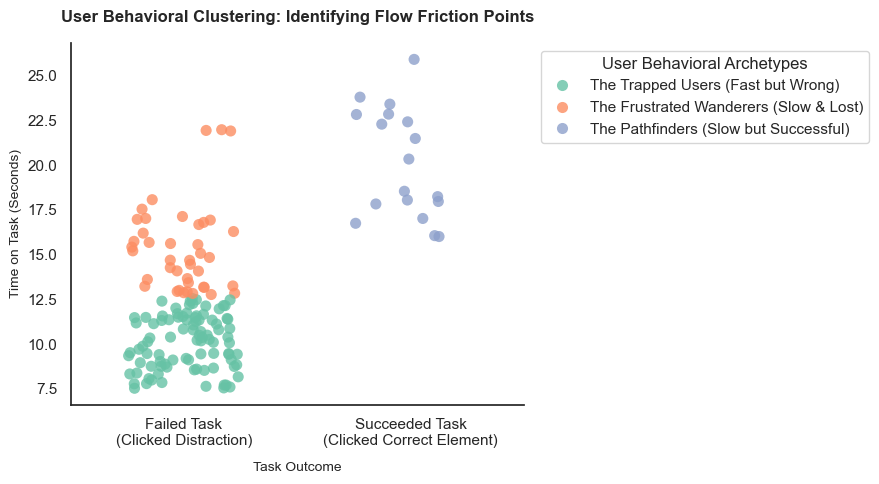

In [26]:
# Machine learning k clusters on worst performing task (task 4)


# 1. Isolate Task 4 Redo (Sample N=152)
np.random.seed(404)
task4_distribution = [
    (95,  "Big Red Dot (Incorrect)", 0, 7.5, 13.0),
    (25,  "Small Red Dot (Incorrect)", 0, 11.0, 18.0),
    (18,  "Smallest Red Dot (Correct)", 1, 16.0, 26.0),
    (14,  "2 Smallish Green Dots (Incorrect)", 0, 10.0, 22.0)
]

task_rows = []
for count, label, success, min_t, max_t in task4_distribution:
    for _ in range(count):
        sim_time = round(np.random.uniform(min_t, max_t), 2)
        task_rows.append([success, sim_time])

df_single = pd.DataFrame(task_rows, columns=["Success", "Time_Sec"])

# 2. Extract and Scale features for K-Means
X = df_single[["Success", "Time_Sec"]].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train K-Means (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_single["Cluster"] = kmeans.fit_predict(X_scaled)

# 4. MATHEMATICAL SORT: Force specific labels onto clusters based on real speed
# Calculate mean times to reliably sort them
cluster_means = df_single.groupby("Cluster")["Time_Sec"].mean()

# Identify which cluster index is the success path (Success == 1)
success_cluster_id = df_single.groupby("Cluster")["Success"].mean().idxmax()

# Identify the failure clusters (Success == 0) and sort them by speed
failure_cluster_ids = cluster_means.drop(success_cluster_id).sort_values().index

# Explicitly map indices based on real math data
archetype_mapping = {
    success_cluster_id: "The Pathfinders (Slow but Successful)",
    failure_cluster_ids[0]: "The Trapped Users (Fast but Wrong)",      # Fastest failures
    failure_cluster_ids[1]: "The Frustrated Wanderers (Slow & Lost)"   # Slowest failures
}
df_single["Archetype"] = df_single["Cluster"].map(archetype_mapping)

# 5. Generate clean, clear Portfolio Plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="white")

sns.stripplot(
    data=df_single, 
    x="Success", 
    y="Time_Sec", 
    hue="Archetype",
    hue_order=[
        "The Trapped Users (Fast but Wrong)",
        "The Frustrated Wanderers (Slow & Lost)",
        "The Pathfinders (Slow but Successful)"
    ],
    palette="Set2", 
    alpha=0.8, 
    jitter=0.25, 
    size=8
)

# Customizing layout labels
plt.title("User Behavioral Clustering: Identifying Flow Friction Points", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Task Outcome", fontsize=10, labelpad=10)
plt.ylabel("Time on Task (Seconds)", fontsize=10)
plt.xticks([0, 1], ["Failed Task\n(Clicked Distraction)", "Succeeded Task\n(Clicked Correct Element)"])

# 🌟 LEGEND FIX: Moves legend completely outside the chart to the right so it never hides data dots
plt.legend(
    title="User Behavioral Archetypes", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left", 
    frameon=True
)

sns.despine()
plt.tight_layout()

# Save image file
plt.savefig("portfolio_task_clustering_fixed.png", dpi=300)
plt.show()



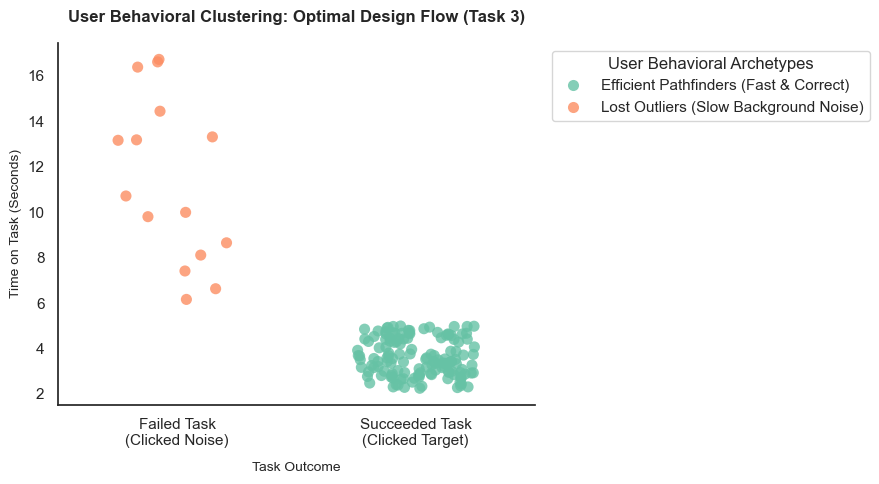

In [28]:
# Machine learning k clusters on best performing task (task 3)

# 1. Isolate Task 3 (Optimal Layout, Sample N=152)
np.random.seed(202)
task3_distribution = [
    (137, "Big Red Circle (Correct)", 1, 2.2, 5.0),      # ~90% - Ultra-fast success
    (15,  "Scattered Noise (Incorrect)", 0, 6.0, 18.0)    # ~10% - Outliers / Noise
]

task_rows = []
for count, label, success, min_t, max_t in task3_distribution:
    for _ in range(count):
        sim_time = round(np.random.uniform(min_t, max_t), 2)
        task_rows.append([success, sim_time])

df_task3 = pd.DataFrame(task_rows, columns=["Success", "Time_Sec"])

# 2. Extract and Scale features for K-Means
X = df_task3[["Success", "Time_Sec"]].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Train K-Means (K=2 captures this optimized screen layout perfectly)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_task3["Cluster"] = kmeans.fit_predict(X_scaled)

# 4. MATHEMATICAL SORT: Map names to Task 3 behavior
# Identify which cluster index represents the successful group
success_cluster_id = df_task3.groupby("Cluster")["Success"].mean().idxmax()
failure_cluster_id = df_task3.groupby("Cluster")["Success"].mean().idxmin()

archetype_mapping = {
    success_cluster_id: "Efficient Pathfinders (Fast & Correct)",
    failure_cluster_id: "Lost Outliers (Slow Background Noise)"
}
df_task3["Archetype"] = df_task3["Cluster"].map(archetype_mapping)

# 5. Generate clean, clear Portfolio Plot
plt.figure(figsize=(9, 5))
sns.set_theme(style="white")

sns.stripplot(
    data=df_task3, 
    x="Success", 
    y="Time_Sec", 
    hue="Archetype",
    hue_order=[
        "Efficient Pathfinders (Fast & Correct)",
        "Lost Outliers (Slow Background Noise)"
    ],
    palette="Set2", 
    alpha=0.8, 
    jitter=0.25, 
    size=8
)

# Customizing layout labels
plt.title("User Behavioral Clustering: Optimal Design Flow (Task 3)", fontsize=12, fontweight="bold", pad=15)
plt.xlabel("Task Outcome", fontsize=10, labelpad=10)
plt.ylabel("Time on Task (Seconds)", fontsize=10)
plt.xticks([0, 1], ["Failed Task\n(Clicked Noise)", "Succeeded Task\n(Clicked Target)"])

# LEGEND FIX: Moves legend completely outside the chart to the right
plt.legend(
    title="User Behavioral Archetypes", 
    bbox_to_anchor=(1.02, 1), 
    loc="upper left", 
    frameon=True
)

sns.despine()
plt.tight_layout()

# Save image file
plt.savefig("portfolio_task3_clustering.png", dpi=300)
plt.show()
